In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Scripts.pam_generation_uniprot_id import set_up_ecoli_pam
from Scripts.pam_generation import setup_ecoli_pam as set_up_ecoli_pam_curated
from Modules.utils.sector_config_functions import change_translational_sector_with_config_dict


# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations
    
ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')
PARAMETER_RESULT_FILE = os.path.join('Results','3_analysis','parameter_files',
                                     'proteinAllocationModel_EnzymaticData_iML1515_2.xlsx')

PARAMETER_RESULT_FILES = [os.path.join('Results','3_analysis','parameter_files',
                                     f'proteinAllocationModel_EnzymaticData_iML1515_{i}.xlsx') for i in range(1,7)]

Loading PAModelpy modules version 0.0.4.1
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


# 1. Load reference data (proteomics and fluxes)

In [2]:
# load proteome data (Schmidt et al. 2016)
proteome_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df.head()


,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,0.446640,0.491074,0.578723,1.026062,0.859739,0.934963,0.875724,0.581381,0.711635,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,0.594492,0.556592,0.813304,1.230390,1.007687,1.109002,1.035491,0.704953,0.963569,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,0.144782,0.117351,0.436610,0.751106,0.721180,1.038963,2.562241,1.997324,3.032313,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,0.144920,0.172421,0.309267,0.442385,0.400793,0.403734,0.413947,0.368480,0.448950,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,0.062205,0.049618,0.225865,0.807285,0.737951,0.676351,0.563197,0.378829,0.420765,1.045406


In [3]:
# load exchange rates for different carbon sources by Gerosa et al. (2015) in Ecoli BW25113
flux_csources = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes_Csources',
                            engine='openpyxl',
                            index_col=1)
flux_csources_df = flux_csources.drop(['Flux (publication)', 'Reversibility'], axis=1)
flux_csources_df.head()

,Acetate,Fructose,Galactose,Glucose,Glycerol,Gluconate,Pyruvate,Succinate,Glucose (flux ratio Glc)
Reaction identifier,,,,,,,,,
EX_ac_e_b,13.584,-3.32866,-1.968939e-08,-6.827019,-0.597000,-5.003982,-11.91391,-3.320974,-0.70717
EX_fru_e_b,0.000,8.32800,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_gal_e_b,0.000,0.00000,1.969000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_glc__D_e_b,0.000,0.00000,0.000000e+00,9.654000,0.000000,0.000000,0.00000,0.000000,1.00000
EX_glyc_e_b,0.000,0.00000,0.000000e+00,0.000000,4.944834,0.000000,0.00000,0.000000,0.00000


# 2. Setup the *Escherichia coli* iML1515 model with new parameters

In [5]:
#setup the model
ecoli_pam_wt = set_up_ecoli_pam(sensitivity=False) # not curation for reference
ecoli_pam_curated = set_up_ecoli_pam_curated(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
    sensitivity = False) # curated for reference
# ecoli_pam_new = set_up_ecoli_pam(PARAMETER_RESULT_FILE,
# #     os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_240730_multi.xlsx'),
#                                  sensitivity=False)

new_ecoli_pams = {alt+1: set_up_ecoli_pam(file, sensitivity=False) for alt, file in enumerate(PARAMETER_RESULT_FILES)}

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:246: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.25

In [5]:
# extract the optimized kcats and do the changes
# mutated_kcats = pd.read_excel(PARAMETER_RESULT_FILE, sheet_name='Best_Individuals')
# mutated_kcats.groupby('run_id')
# for i, row in mutated_kcats.iterrows():
#     kcat_dict = {row['rxn_id']:{row['direction']:row['kcat[s-1]']}}
#     ecoli_pam_new.change_kcat_value(enzyme_id=row['enzyme_id'], kcats = kcat_dict)

# 3. Check internal flux distribution

In [6]:
def remove_suffixes(strings):
    modified_strings = []
    for string in strings:
        if string.endswith('_f') or string.endswith('_b'):
            modified_strings.append(string[:-2])  # Remove last two characters
        else:
            modified_strings.append(string)  # Keep the string unchanged
    return modified_strings

In [150]:
def enzyme_concentration(enz_var):
    fwd_value = enz_var.forward_variable.primal
    rev_value = enz_var.reverse_variable.primal
    return fwd_value+rev_value

def run_simulations(pamodel, substrate_ids, substrate_rates, 
                    fluxes_to_save = None, proteins_to_save = None,
                    transl_sector_config = True) -> list:
    
    def append_enzymes_to_protein_df(protein_df, enzid, total_conc, 
                                     pamodel, substrate_id, substrate_rate):
        enzyme = pamodel.enzyme_variables.get_by_id(enzid)
        conc = enzyme_concentration(enzyme)
        total_conc += conc
        protein_df.loc[len(protein_df)] = [enzid, conc, pamodel.objective.value, substrate_id, substrate_rate]
        return protein_df, total_conc
    
    if transl_sector_config: 
        transl_sector_config = {'slope': pamodel.sectors.get_by_id('TranslationalProteinSector').tps_mu[0],
                    'intercept': pamodel.sectors.get_by_id('TranslationalProteinSector').tps_0[0]}

        change_translational_sector_with_config_dict(pamodel, transl_sector_config, 'EX_glc__D_e')
    
    if fluxes_to_save is not None:
        fluxes = pd.DataFrame(columns = ['substrate_id', 'substrate_rate']+fluxes_to_save)
    if proteins_to_save is not None:
        proteins = pd.DataFrame(columns = ['uniprot_id', 'fraction', 'growth_rate', 'substrate_id', 'substrate_rate'])
    
    pamodel.change_reaction_bounds(rxn_id='EX_glc__D_e',
                                       lower_bound=0, upper_bound=0)
    
    for substrate_id, substrate_rate in zip(substrate_ids, substrate_rates):
        pamodel.change_reaction_bounds(rxn_id=substrate_id,
                                       lower_bound=substrate_rate, upper_bound=0)
        print('Running simulations with ', substrate_rate, 'mmol of ', substrate_id,' /g_cdw/h of substrate going into the system')
        sol_pam =pamodel.optimize()
        if pamodel.solver.status == 'optimal' and pamodel.objective.value>0:
            if fluxes_to_save is not None:
                solution_flux = [substrate_id, substrate_rate]+ \
                    [sol_pam[rxn] if rxn in pamodel.reactions else np.NaN for rxn in fluxes_to_save]
                fluxes.loc[len(fluxes)] = solution_flux
            if proteins_to_save is not None:
                total_conc = 0
                for enzid in proteins_to_save:
                    if enzid not in pamodel.enzyme_variables:
                        enzs = pamodel.get_enzymecomplex_containing_enzyme(enzid)
                        for enz in enzs:
                            proteins, total_conc = append_enzymes_to_protein_df(proteins, enz.id, total_conc,
                                                                                pamodel, substrate_id, substrate_rate)
                    else:
                         proteins, total_conc = append_enzymes_to_protein_df(proteins, enzid, total_conc,
                                                                                pamodel, substrate_id, substrate_rate)
        
        pamodel.change_reaction_bounds(rxn_id=substrate_id,
                                       lower_bound=0, upper_bound=1e6)
                
    if proteins_to_save is not None: 
        return proteins
    if fluxes_to_save is not None:
        return fluxes

In [8]:
def calculate_error_for_reactions(validation_df: pd.DataFrame,
                                   flux_df: pd.DataFrame,
                                  rxns_to_validate: list) -> float:
    # calculate error for different exchange rates
    error = []
    for rxn, substrate_id in zip(rxns_to_validate, flux_df.substrate_id):
        # only select the rows which are filled with data
        validation_data = validation_df.dropna(axis=0, subset=rxn)
        validation_data = validation_data.loc[substrate_id]
        # if there are no reference data points, continue to the next reaction
        if len(validation_data) == 0:
            continue

        r_squared = calculate_r_squared_for_reaction(rxn, validation_df, substrate_id,
                                                           flux_df[flux_df.substrate_id == substrate_id])
        error += [r_squared]
    return error

def calculate_r_squared_for_reaction(reaction_id: str, validation_data: pd.DataFrame,
                                     substrate_uptake_id: str,
                                      fluxes: pd.DataFrame) -> float:
    substr_rxn = substrate_uptake_id
    # Take the absolute value of substrate uptake to avoid issues with reaction directionality
    validation_data[substr_rxn] = [round(abs(flux),4) for flux in validation_data[substr_rxn]]
    simulated_data = pd.DataFrame({substr_rxn: [round(abs(flux),4) for flux in fluxes['substrate_rate']],
                                   'simulation': fluxes[reaction_id]})
    ref_data_rxn = pd.merge(validation_data,simulated_data,on=substr_rxn, how='inner')
    # error: squared difference
    ref_data_rxn = ref_data_rxn.assign(error=lambda x: (x[reaction_id] - x['simulation']) ** 2)

    # calculate R^2:
    data_average = np.nanmean(validation_data[reaction_id])
    residual_ss = np.nansum(ref_data_rxn.error)
    total_ss = np.nansum([(data - data_average) ** 2 for data in ref_data_rxn[reaction_id]])
    # calculating r_squared is only feasible of the numerator and the denomenator are both nonzero
    if (residual_ss == 0) | (total_ss == 0):
        r_squared = 0
    else:
        r_squared = 1 - residual_ss / total_ss
    return r_squared

def calculate_difference_simulation_experiment(validation_df, flux_df, rxns_to_validate, substr_rxn):
    differences = []
    for rxn in rxns_to_validate:
        # only select the rows which are filled with data
        validation_data = validation_df.dropna(axis=0, subset=rxn)
        # if there are no reference data points, continue to the next reaction
        if len(validation_data) == 0:
            continue
        validation_data[substr_rxn] = [round(abs(flux),4) for flux in validation_data[substr_rxn]]
        simulated_data = pd.DataFrame({substr_rxn: [round(abs(flux_df['substrate_rate']),4)],
                                   'simulation': flux_df[rxn]})
        ref_data_rxn = pd.merge(validation_data,simulated_data,on=substr_rxn, how='inner')
        # error: squared difference
        differences += [row[rxn] - row['simulation'] if not np.isnan(row.simulation) else row[rxn] for i,row in ref_data_rxn.iterrows()]
    return differences

## 3.1 Parse dataframes to validate the flux distribution

In [9]:
# Get the data for growth on multiple carbon sources from Gerosa et al. (2015)
# Make sure all the fluxes of backward reactions are inverted to match the model directionality
fluxes_to_simulate = flux_csources_df.copy()
new_indices = []
for i, row in fluxes_to_simulate.iterrows():
    if isinstance(row.name, str):
        if row.name[-2:] == '_b':
            new_indices.append(row.name[:-2])
            fluxes_to_simulate.loc[row.name]= -row
        else: 
            new_indices.append(row.name)
    else:
        new_indices.append(row.name)
            
fluxes_to_simulate.index = new_indices
fluxes_to_simulate_parsed = fluxes_to_simulate[fluxes_to_simulate.index.notnull()]
fluxes_to_simulate_parsed = fluxes_to_simulate_parsed.rename(index = {'BIOMASS_Ec_iML1515_WT_75p37M':'BIOMASS_Ecoli_core_w_GAM'}).drop('Glucose (flux ratio Glc)', axis = 1)

In [10]:
# extract the validation data and substrate information for each carbon source
flux_mapper = {col: fluxes_to_simulate_parsed.index[i] for i,col in enumerate(fluxes_to_simulate_parsed.columns)}
fluxes_to_save = []
# Get the fluxes we want to save
for flux in fluxes_to_simulate_parsed.index:
    if isinstance(flux, str):
        fluxes_to_save += [f for f in flux.split(', ')]

#parse the fluxes such that we can run and validate simulations easily
validation_df = pd.DataFrame(columns = list(fluxes_to_simulate_parsed.index))
substrate_ids = []
substrate_uptake = []
for substrate, fluxes in fluxes_to_simulate_parsed.items():
    substrate_ids += [flux_mapper[substrate]]
    substrate_uptake += [fluxes.loc[flux_mapper[substrate]]]
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)

validation_df.index = list(flux_mapper.values())
validation_df

,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,TKT2,PPC,PPCK,ICDHyr,SUCDi,FUM,"MDH, MDH2, MDH3","ME1, ME2",ICL,BIOMASS_Ec_iML1515_core_75p37M
EX_ac_e,-1.358400e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.358425e-07,0.00000,...,0.718249,1.774145,3.114281e+00,4.696417,8.404765,8.404765,10.671300,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.328660e+00,-8.328,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,8.327452e-08,0.00000,...,1.788933,3.545669,3.589203e-01,4.566119,3.877105,3.877105,2.227706,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,1.968939e-08,-0.000,-1.969,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.968946e-08,0.00000,...,0.058569,0.377386,8.489495e-01,0.496177,1.260858,1.260858,2.285119,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.827019e+00,-0.000,-0.000,-9.654,-0.000000,-0.000000,-0.000,-0.000,9.653732e-08,0.00000,...,0.584644,2.453331,5.408740e-01,2.977971,2.138073,2.138073,2.138073,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,5.970003e-01,-0.000,-0.000,-0.000,-4.944834,-0.000000,-0.000,-0.000,1.013568e-07,0.00000,...,0.904380,1.376469,-1.003518e-07,2.464836,1.840459,1.840459,1.840459,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.003982e+00,-0.000,-0.000,-0.000,-0.000000,-7.283923,-0.000,-0.000,7.283677e-08,0.00000,...,0.170985,1.943350,-7.211081e-08,1.154034,0.182358,0.182358,0.182358,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,1.191391e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-26.714,-0.000,0.000000e+00,1.15701,...,0.090131,2.489449,1.164803e+00,7.979320,7.518256,7.518256,7.427797,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.320974e+00,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-15.902,1.139998e+00,0.00000,...,1.369847,2.016110,2.971789e+00,3.038949,18.370434,17.230436,4.950705,1.239618e+01,1.164515e-01,0.5100


## 3.2 Run simulations

In [12]:
kwargs = {'substrate_ids': substrate_ids, 
          'substrate_rates': substrate_uptake,
          'fluxes_to_save' : fluxes_to_save}
# for each study, run simulations
fluxes_curated = run_simulations(ecoli_pam_curated, **kwargs)
print('\n')
fluxes_wt = run_simulations(ecoli_pam_wt,**kwargs)
print('\n')
# fluxes_new = run_simulations(ecoli_pam_new, **kwargs)

fluxes_new_dict = {alt: run_simulations(pam, **kwargs) for alt, pam in new_ecoli_pams.items()}

Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running simulations with  -1.969 mmol of  EX_gal_e  /g_cdw/h of substrate going into the system
Running simulations with  -9.654 mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  -7.28392319195215 mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  -26.714 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -15.902 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system


Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running 

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with  -9.654 mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  -7.28392319195215 mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  -26.714 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -15.902 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system


Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running simulations with  -1.969 mmol of  EX_gal_e  /g_cdw/h of substrate going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with  -9.654 mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  -7.28392319195215 mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  -26.714 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -15.902 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running simulations with  -1.969 mmol of  EX_gal_e  /g_cdw/h of substrate going into the system
Running simulations with  -9.654 mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_glyc_e  /g_cdw/h of substrate going into the sy

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with  -9.654 mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  -7.28392319195215 mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  -26.714 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -15.902 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system


In [13]:
#calculate R^2 value between simulations and experiments
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save)
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


# error_new = calculate_error_for_reactions(validation_df,
#                                                  fluxes_new,
#                                                  fluxes_to_save[1:])
error_new_dict = {alt: calculate_error_for_reactions(validation_df,
                                                  fluxes,
                                                  fluxes_to_save[1:]) for alt, fluxes in fluxes_new_dict.items()}
for alt, error_list in error_new_dict.items():
    print('R^2 values for the model with the optimized parameters: ', np.nanmean(error_list), f'(alternative {alt})')



R^2 values for the model with published parameter set : -3.6931877771952113
R^2 values for the model with parameters from GotEnzymes:  -2.239297979796015
R^2 values for the model with the optimized parameters:  -3.01750016640358 (alternative 0)
R^2 values for the model with the optimized parameters:  -0.03826532697204951 (alternative 1)
R^2 values for the model with the optimized parameters:  -0.03826532697204951 (alternative 2)
R^2 values for the model with the optimized parameters:  -0.03826532697204951 (alternative 3)
R^2 values for the model with the optimized parameters:  -0.03826532697204951 (alternative 4)
R^2 values for the model with the optimized parameters:  -2.8510372387174625 (alternative 5)


## 3.2 Visualize the simulation results for the different models

In [14]:
# validation_df_1.index = validation_df.index.str.split(', ')
validation_df_1 = validation_df.T.reset_index()
validation_df_1['index'] = validation_df_1['index'].str.split(', ')
validation_df_1 = validation_df_1.explode('index').set_index('index').T
validation_df_1
# validation_df = validation_df.explode()

index,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ec_iML1515_core_75p37M
EX_ac_e,13.5840,0.000,0.000,0.000,0.0000,0.0000,0.000,0.000,1.358425e-07,0.00000,...,4.696417,8.404765,8.404765,10.671300,10.671300,10.671300,1.871037e+00,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.3287,8.328,0.000,0.000,0.0000,0.0000,0.000,0.000,8.327452e-08,0.00000,...,4.566119,3.877105,3.877105,2.227706,2.227706,2.227706,1.651610e+00,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,0.0000,0.000,1.969,0.000,0.0000,0.0000,0.000,0.000,1.968946e-08,0.00000,...,0.496177,1.260858,1.260858,2.285119,2.285119,2.285119,5.237651e-04,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.8270,0.000,0.000,9.654,0.0000,0.0000,0.000,0.000,9.653732e-08,0.00000,...,2.977971,2.138073,2.138073,2.138073,2.138073,2.138073,-9.557242e-08,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,0.5970,0.000,0.000,0.000,4.9448,0.0000,0.000,0.000,1.013568e-07,0.00000,...,2.464836,1.840459,1.840459,1.840459,1.840459,1.840459,-1.003463e-07,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.0040,0.000,0.000,0.000,0.0000,7.2839,0.000,0.000,7.283677e-08,0.00000,...,1.154034,0.182358,0.182358,0.182358,0.182358,0.182358,-7.210584e-08,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,11.9139,0.000,0.000,0.000,0.0000,0.0000,26.714,0.000,0.000000e+00,1.15701,...,7.979320,7.518256,7.518256,7.427797,7.427797,7.427797,1.930607e-01,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.3210,0.000,0.000,0.000,0.0000,0.0000,0.000,15.902,1.139998e+00,0.00000,...,3.038949,18.370434,17.230436,4.950705,4.950705,4.950705,1.239618e+01,1.239618e+01,1.164515e-01,0.5100


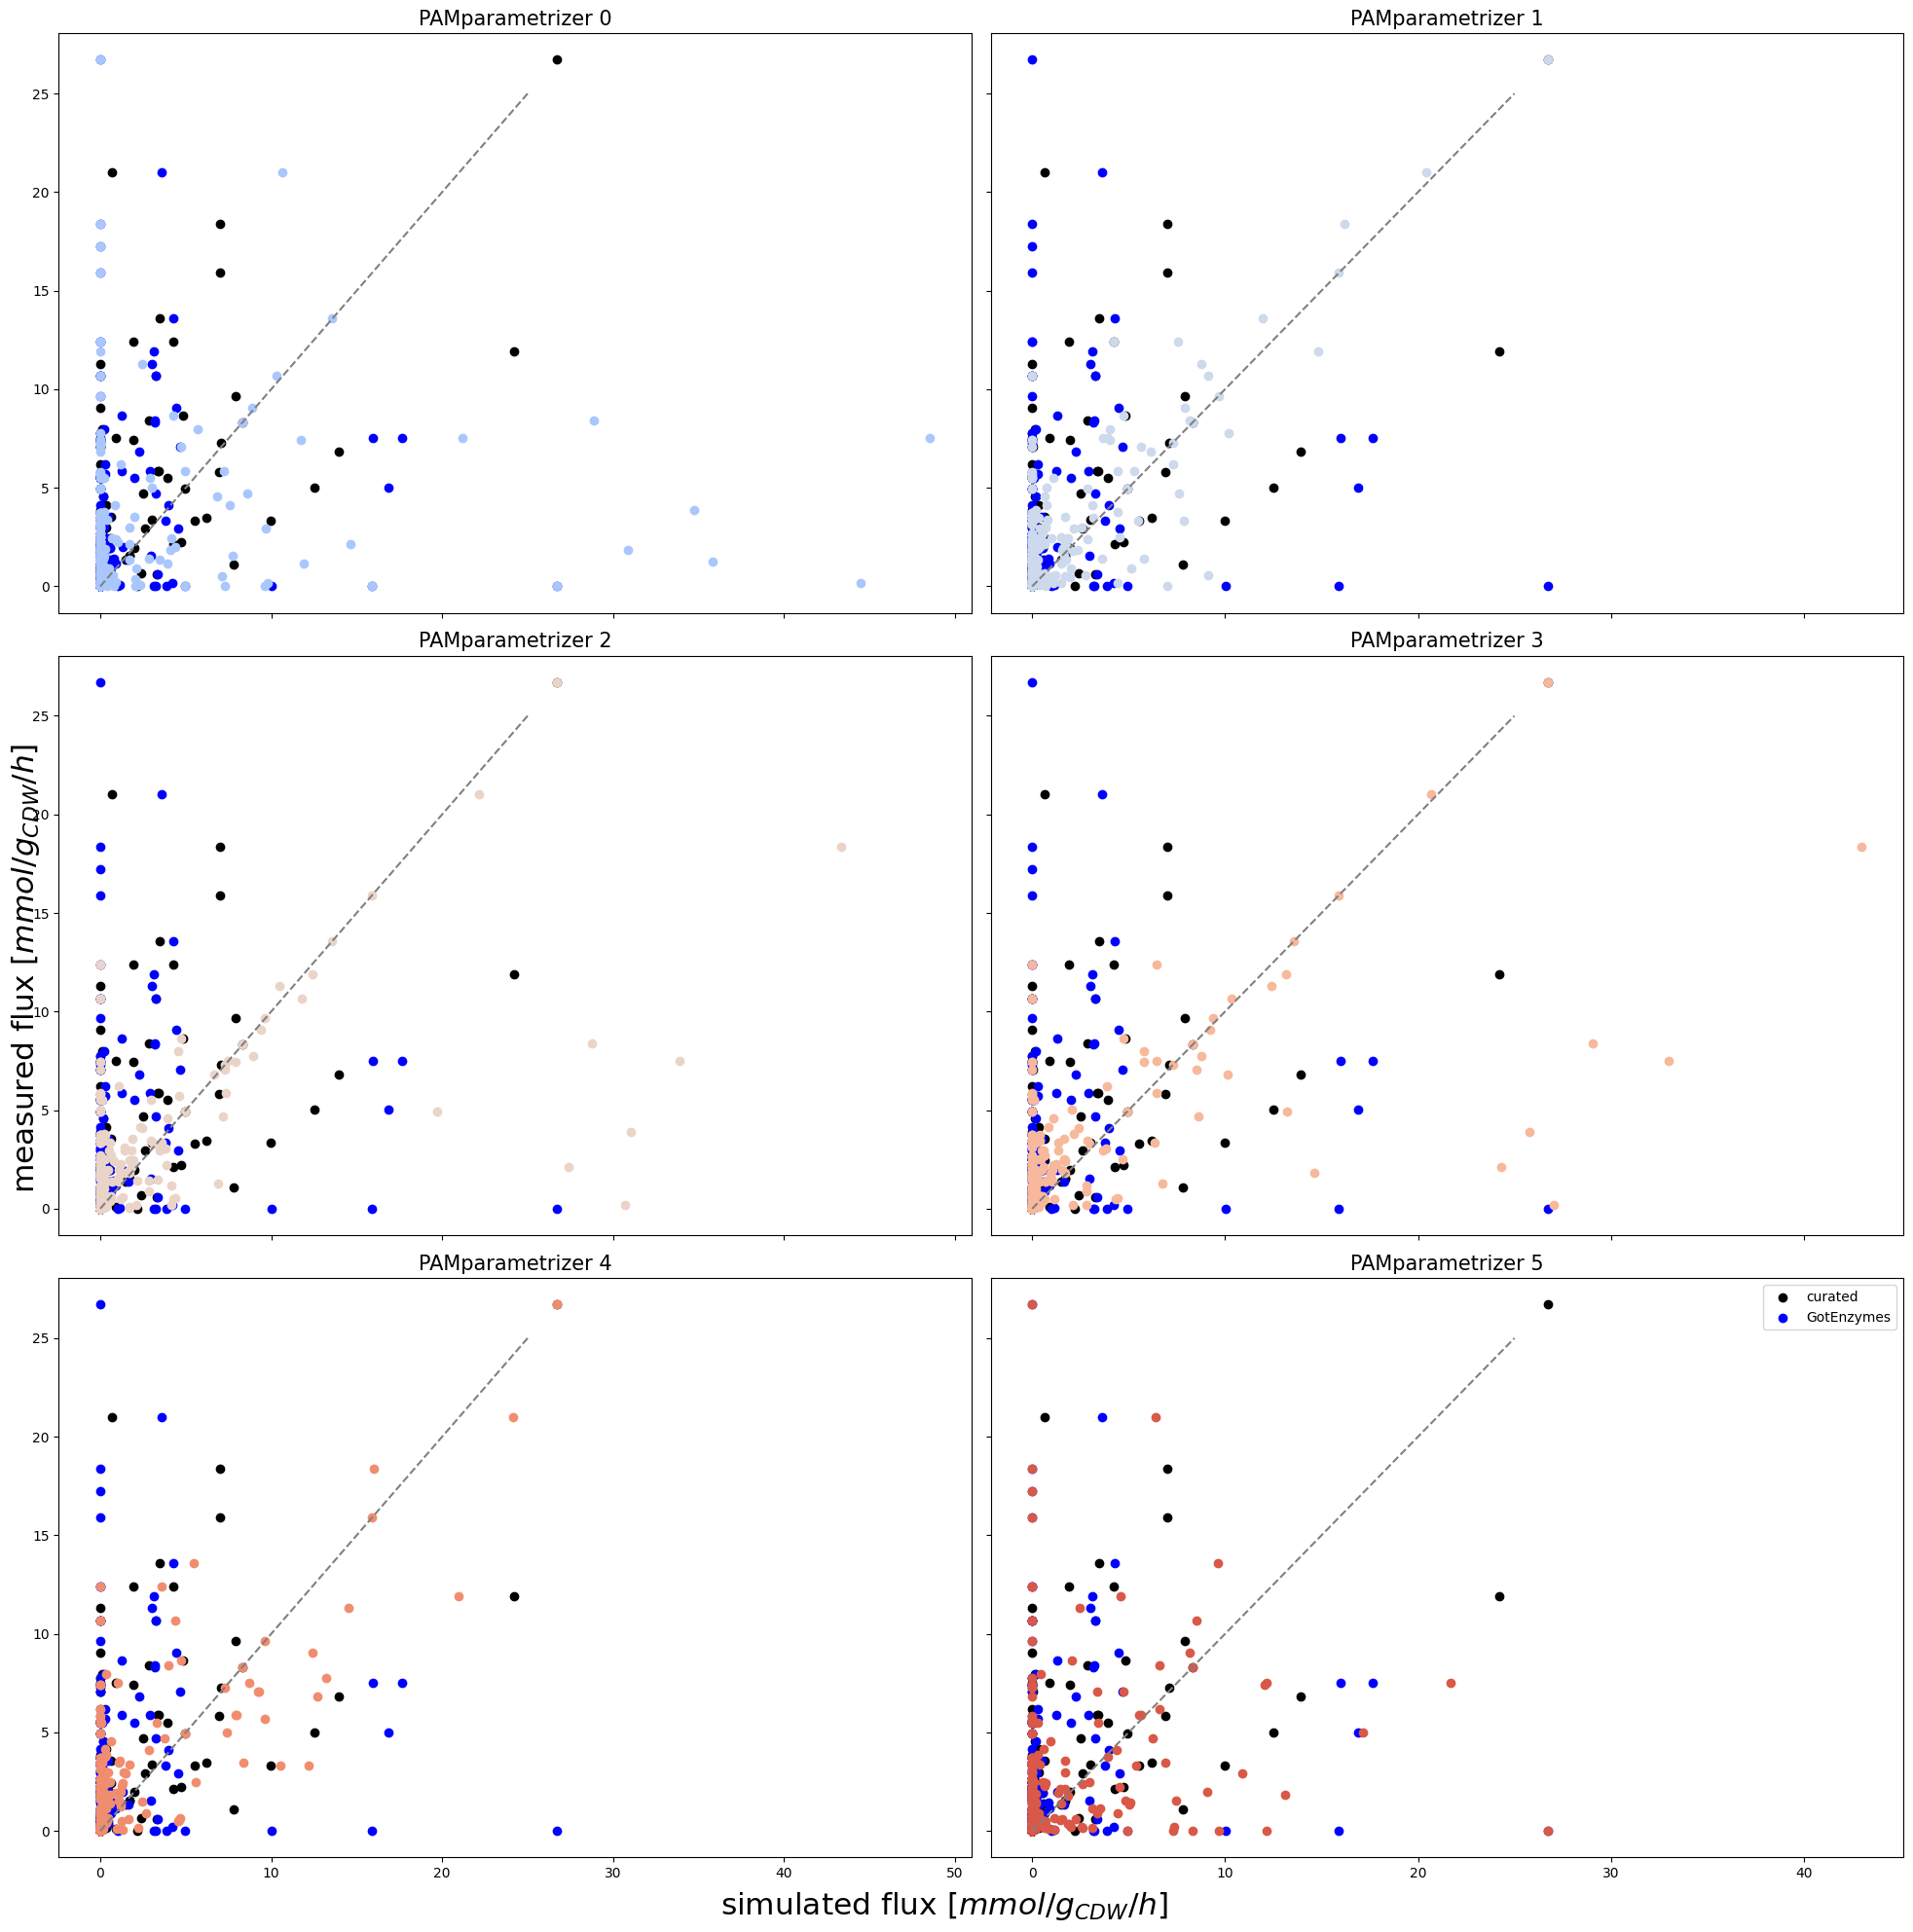

In [48]:
models = ['GotEnzymes','Curated'] + [f'PAMparametrizer {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))

fig, axs = plt.subplots(nrows = int(len(fluxes_new_dict)/2), ncols = 2, sharey='row', sharex='col', figsize = (20,20))
axs = axs.flatten()

for alt, fluxes_new in fluxes_new_dict.items():
    ax = axs[alt]
    curated = []
    wt = []
    new = []
    validation = []
    for i in range(len(fluxes_curated)):
        curated += [abs(flx) for flx in fluxes_curated.iloc[i].to_list()[2:]]
        if i<len(fluxes_wt):
            wt += [abs(flx) for flx in fluxes_wt.iloc[i].to_list()[2:]]
        else:
            wt += [0]*len(fluxes_curated.iloc[i].to_list()[2:])
        if i<len(fluxes_new):
            new += [abs(flx) for flx in fluxes_new.iloc[i].to_list()[2:]]
        else:
            new += [0]*len(fluxes_curated.iloc[i].to_list()[2:])
        validation += validation_df_1.iloc[i].abs().to_list()
    
    ax.plot([0,25], [0,25], linestyle = 'dashed', color='grey')
    ax.scatter(curated, validation, label = 'curated', color = 'black')
    ax.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
    ax.scatter(new, validation, color = cmap[f'PAMparametrizer {alt}'])#, label = f'PAMparametrizer {alt}'
    ax.set_title(f'PAMparametrizer {alt}', fontsize = fontsize)

fig.supxlabel('simulated flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
fig.supylabel('measured flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
fluxes_curated

,substrate_id,substrate_rate,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ec_iML1515_core_75p37M
0,EX_ac_e,-13.584000,-3.455140,0.000,0.000,0.000000,0.000000,0.00000,0.000,0.000000,...,2.533140,2.843244,NaN,3.250145,0.0,0.0,0.000000,0.000000,0.359228,0.045713
1,EX_fru_e,-8.328000,9.979174,-8.328,0.000,0.000000,0.000000,0.00000,0.000,0.000000,...,0.150942,0.000000,NaN,-4.746132,0.0,0.0,0.000000,0.000000,0.000000,0.140386
2,EX_gal_e,-1.969000,2.193617,0.000,-1.969,0.000000,0.000000,0.00000,0.000,0.000000,...,0.434259,0.333768,NaN,0.431292,0.0,0.0,0.000000,0.000000,0.000000,0.093513
3,EX_glc__D_e,-9.654000,13.940116,0.000,0.000,-7.918819,0.000000,0.00000,0.000,0.000000,...,0.152400,0.000000,NaN,-4.261890,0.0,0.0,0.000000,0.000000,0.000000,0.141742
4,EX_glyc_e,-4.944834,3.287644,0.000,0.000,0.000000,-4.944834,0.00000,0.000,0.000000,...,0.133106,0.000071,NaN,0.128977,0.0,0.0,0.000000,0.000000,0.000000,0.123798
5,EX_glcn_e,-7.283923,12.503158,0.000,0.000,0.000000,0.000000,-7.08271,0.000,0.000000,...,0.129303,0.000000,NaN,-0.341454,0.0,0.0,0.000000,0.000000,0.000000,0.120261
6,EX_pyr_e,-26.714000,24.220909,0.000,0.000,0.000000,0.000000,0.00000,-26.714,0.000000,...,0.126175,0.922261,NaN,1.966839,0.0,0.0,0.000000,0.000000,0.922194,0.117351
7,EX_succ_e,-15.902000,5.552484,0.000,0.000,0.000000,0.000000,0.00000,0.000,-7.028954,...,0.118594,7.028943,NaN,0.000000,0.0,0.0,4.250417,1.911692,0.000000,0.110300


In [75]:
from scipy.stats import permutation_test

def statistic(x, y):
    return np.median(x) - np.median(y)

errors_curated = all_differences[all_differences['Model']=='Curated'].Difference
errors_2 = all_differences[all_differences['Model']=='PAMparametrizer 2'].Difference


result = permutation_test((errors_curated, errors_2), statistic, alternative="greater", n_resamples=10000)
print(f"Statistic: {result.statistic}, p-value: {result.pvalue}")

Statistic: 0.3311009922628915, p-value: 0.016998300169983


In [115]:
def plot_significant_annotation(ax, column, sign, compare_df, dodge_factor):
        # Add annotation for significance
        x1, x2 = 1, column
        y, h = compare_df.Difference.quantile(0.88)+ dodge_factor, 0.7  # Dynamically adjust y position
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        ax.text((x1 + x2) * 0.5, y + h*0.6, sign, ha='center', va='bottom', fontsize=fontsize, color='k')

PAMparametrizer 0: U-statistic = 39453.5, p-value = 0.0014225275747311698
PAMparametrizer 1: U-statistic = 41634.5, p-value = 0.10083870190141025
PAMparametrizer 2: U-statistic = 44367.5, p-value = 0.00335995872351591
PAMparametrizer 3: U-statistic = 43542.5, p-value = 0.011373752748988206
PAMparametrizer 4: U-statistic = 41970.0, p-value = 0.0731431360446726
PAMparametrizer 5: U-statistic = 36900.0, p-value = 0.06609839501395602


/tmp/ipykernel_174215/3803766687.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)
/tmp/ipykernel_174215/3803766687.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)


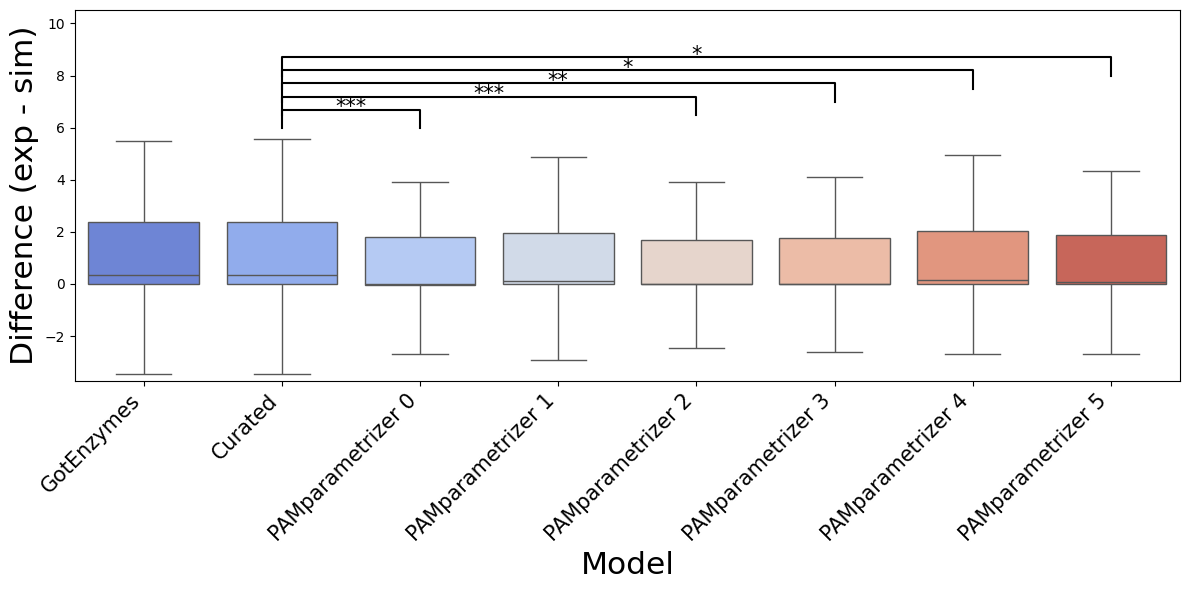

In [116]:
fontsize = 15
models = ['GotEnzymes', 'Curated'] + [f'PAMparametrizer {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))

# Prepare the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Combine data into a DataFrame
all_differences = pd.DataFrame()
curated_differences = None  # Placeholder for Curated errors
num_significant = 0

for col, (model, sub_df) in enumerate(zip(models, [fluxes_wt, fluxes_curated] + list(fluxes_new_dict.values()))):
    differences = []
    for _, row in sub_df.iterrows():
        substrate_id = row['substrate_id']
        difference = calculate_difference_simulation_experiment(
            validation_df_1, row, fluxes_to_save[1:], substrate_id)
        differences += difference

    temp_df = pd.DataFrame({'Model': [model] * len(differences), 'Difference': differences})
    
    # Store curated differences for comparison
    if model == 'Curated':
        curated_differences = differences
        curated_diff_df = temp_df[temp_df.Model == 'Curated']
    elif 'PAMparametrizer' in model:
        # Statistical test
        stat, p = mannwhitneyu(curated_differences, differences, alternative='greater')
        print(f"{model}: U-statistic = {stat}, p-value = {p}")
        if p < 0.075:
            sign = '*'
        if p < 0.05:
            sign = '**'
        if p < 0.01:
            sign = '***'
        if p < 0.075:
            num_significant += 1
            plot_significant_annotation(ax, col, sign, curated_diff_df, num_significant*0.5)

    # Append to the main DataFrame
    all_differences = pd.concat([all_differences, temp_df], ignore_index=True)

# Boxplot or Violin Plot
sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
ax.set_ylim([all_differences['Difference'].quantile(0.05), all_differences['Difference'].quantile(0.95)+3])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel('Difference (exp - sim)', fontsize=fontsize * 1.5)

plt.tight_layout()
plt.show()

In [74]:
median_2 = np.median(errors_2)
adjusted_model_1 = errors_curated - median_2
adjusted_model_2 = errors_2 - median_2

stat, p = ranksums(adjusted_model_1, adjusted_model_2, alternative="two-sided")
print(f"Statistic: {stat}, p-value: {p}")

Statistic: 2.69917875119782, p-value: 0.006951082955323097


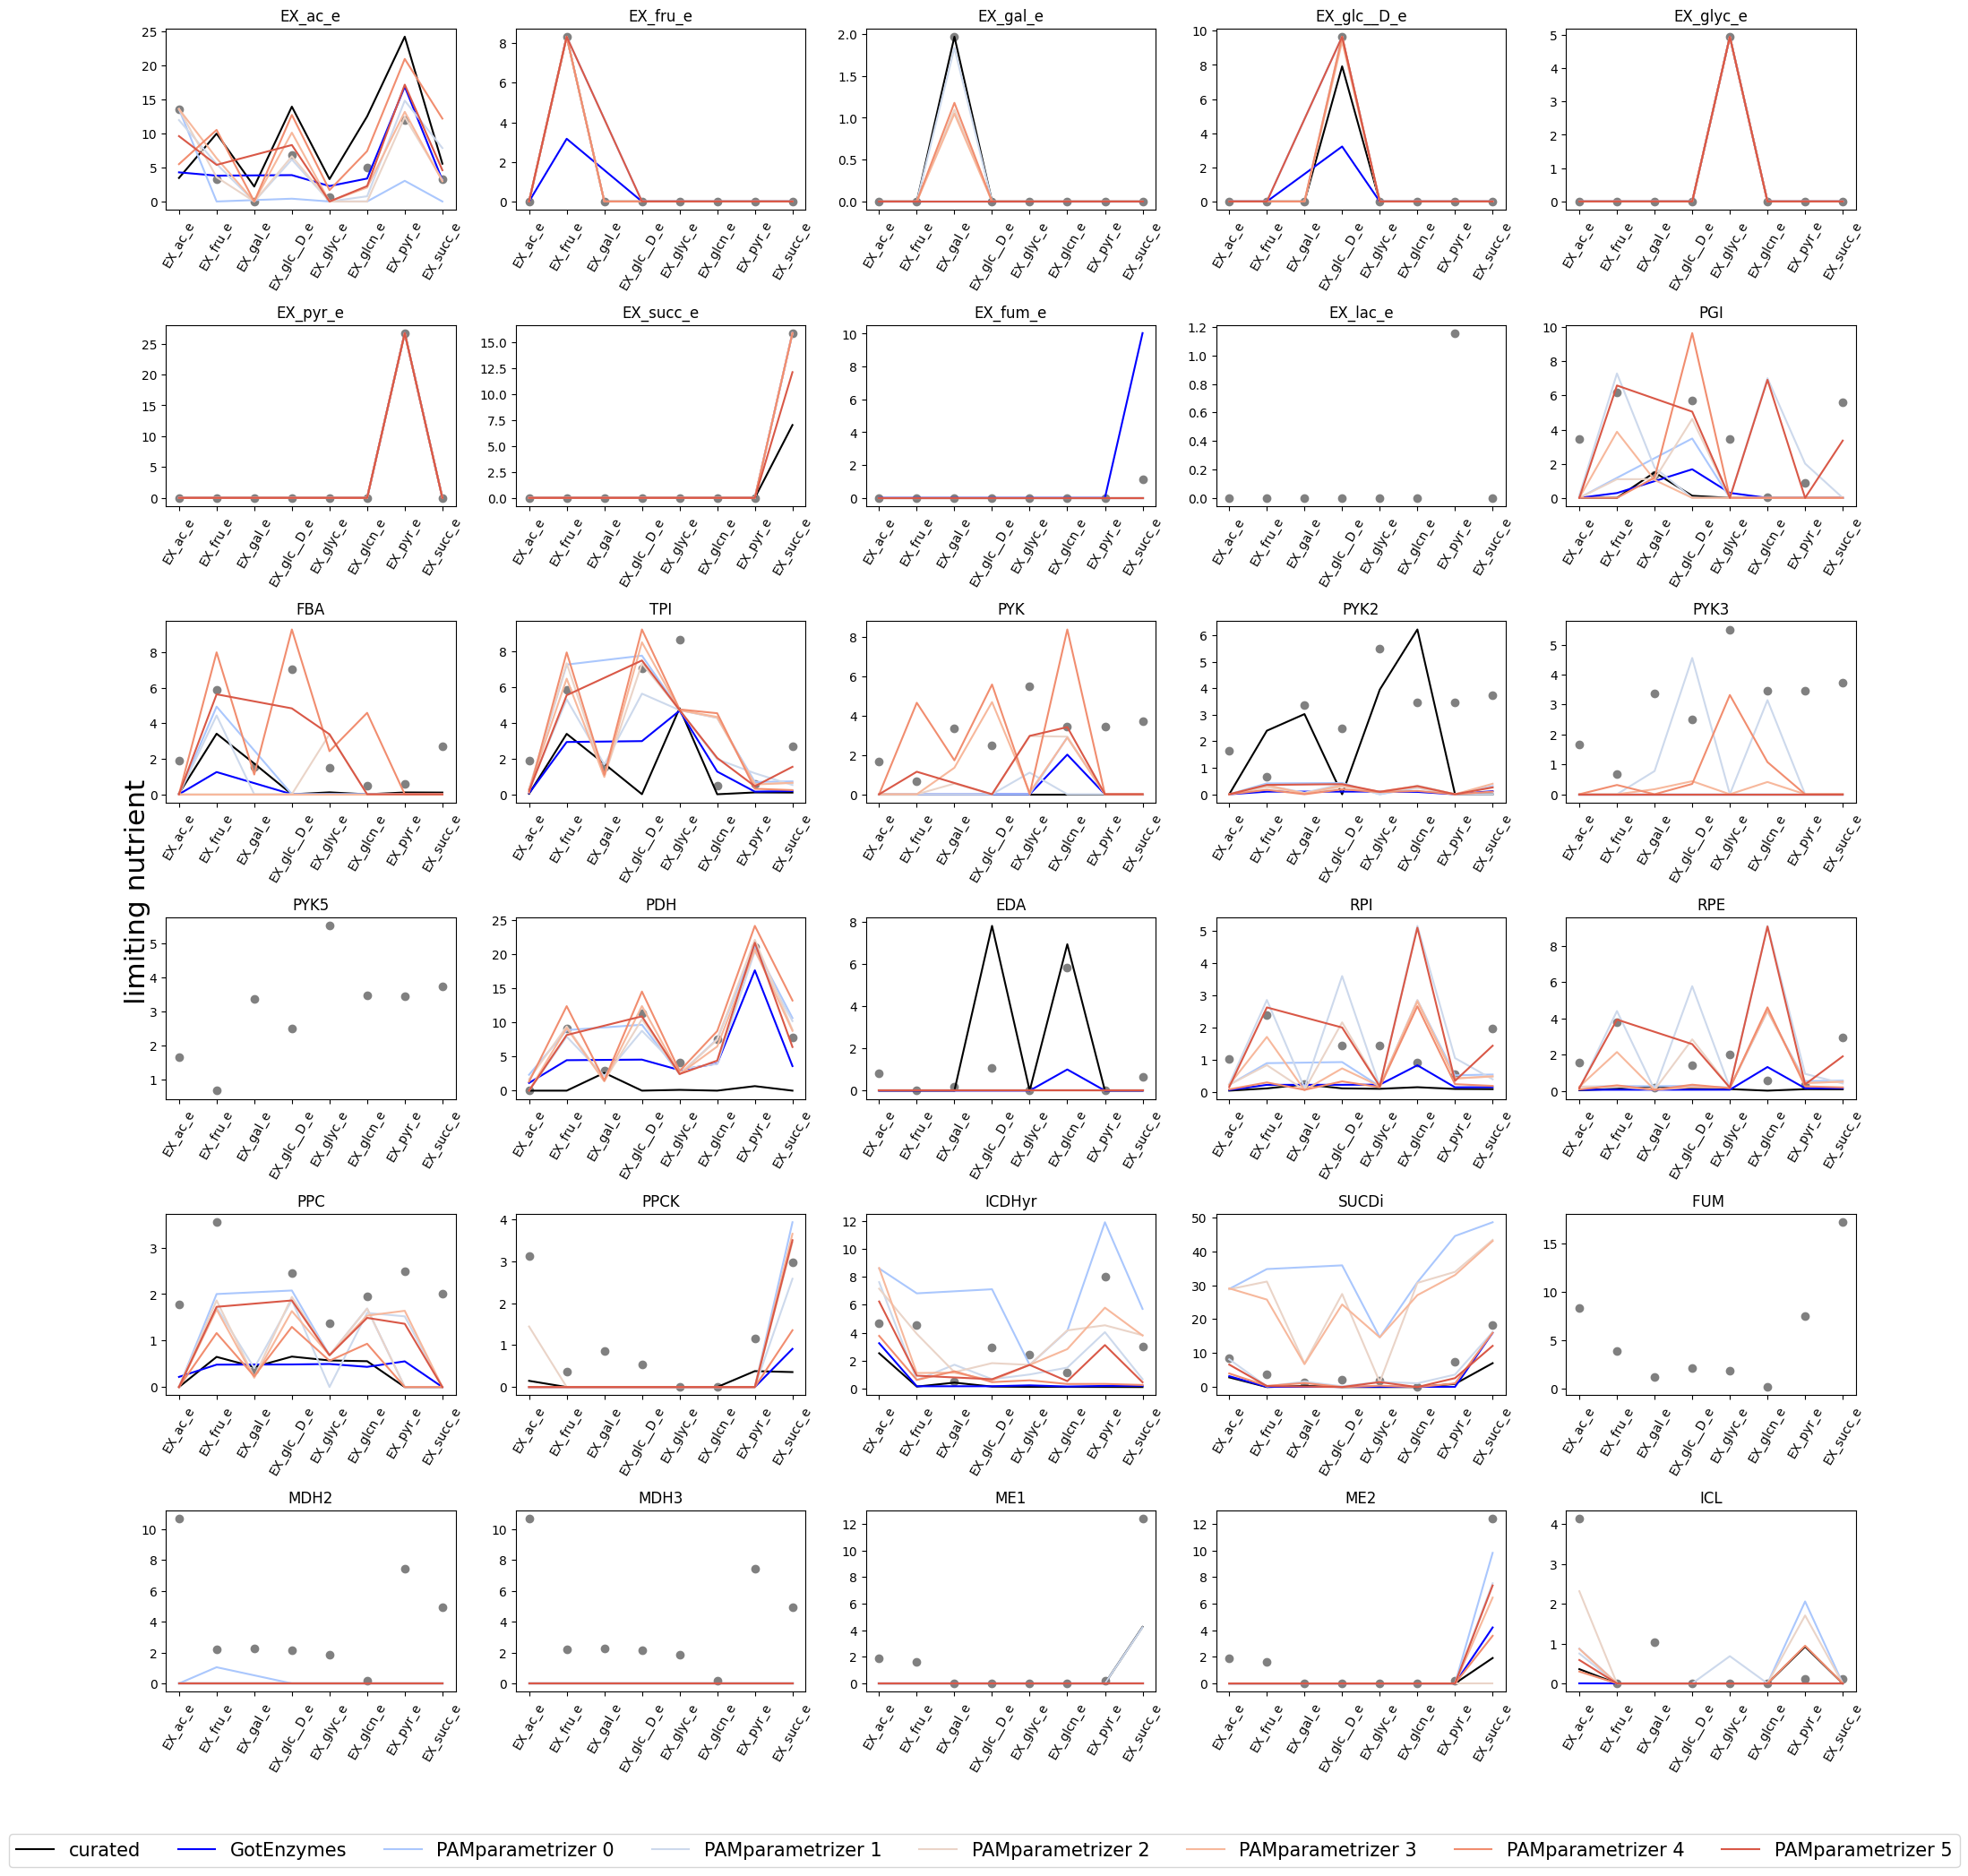

In [41]:
# visualize per flux
fig, axs = plt.subplots(ncols = 5, nrows = 6, figsize = [20,20])
substrate_ids_cur = fluxes_curated.substrate_id
substrate_ids = fluxes_new_dict[1].substrate_id


#make the plot panels for each reaction
fig_reactions = []
for i in range(0,36,6):
    fig_reactions += [[rxn for rxn in fluxes_to_save[i:i+5]]]

# plot all reactions
for j in range(6):
    reactions_to_plot = fig_reactions[j]
    for i, rxn in enumerate(reactions_to_plot):
        validation = validation_df_1[rxn]
        axs[j,i].scatter(substrate_ids_cur, validation_df_1.loc[substrate_ids_cur, rxn].abs(), color = 'grey')
        axs[j,i].plot(substrate_ids_cur, fluxes_curated[rxn].abs(), label = 'curated', color = 'black')
        axs[j,i].plot(fluxes_wt['substrate_id'], fluxes_wt[rxn].abs(),label = 'GotEnzymes', color = 'blue')
        for alt, fluxes in fluxes_new_dict.items():
            axs[j,i].plot(fluxes['substrate_id'], fluxes[rxn].abs(), label = f'PAMparametrizer {alt}', 
                          color = cmap[f'PAMparametrizer {alt}'])

#         axs[j,i].plot(substrate_ids, fluxes_new[rxn].abs(), label = 'PAMparametrizer', color = 'red')
        axs[j,i].set_title(rxn)
        axs[j,i].tick_params(axis='x', labelrotation=60)

        
# Shrink current axis's height by 10% on the bottom
box = axs[j,i].get_position()
axs[j,i].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
        
handles, labels = axs[j,i].get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.05),ncols = 8, fontsize= fontsize)

fig.supylabel('flux rate [mmol/gCDW/h]', fontsize = fontsize*1.5)
fig.supylabel('limiting nutrient', fontsize = fontsize*1.5)

plt.tight_layout()

plt.show()

# 4. Check protein distribution (glucose as C source)

## 4.1 Load the reference data from Schmidt et al (2011) and normalize the values

In [117]:
proteome_csources = proteome_df[['Acetate', 'Fructose', 'Succinate', 'Pyruvate', 'Glycerol']] #unit: fg/cell
proteome_csources

,Acetate,Fructose,Succinate,Pyruvate,Glycerol
Bnumber,,,,,
b3988,0.561253,1.162894,7.116349e-01,0.702820,0.732347
b3987,0.665163,1.317061,9.635688e-01,0.928398,0.936990
b0118,3.543745,1.362394,3.032313e+00,2.543362,1.674174
b2557,0.337313,0.564445,4.489504e-01,0.635390,0.485143
b3212,0.369212,1.045406,4.207655e-01,0.458132,0.597161
...,...,...,...,...,...
NaN,0.000097,NaN,2.050574e-04,0.000183,0.000170
NaN,0.000249,0.000001,1.026332e-06,0.000419,0.000252
NaN,0.000770,0.001285,2.757719e-04,0.000805,0.000709


In [122]:
# match the gene ids to the associated enzymes
gene_enzyme_mapper_df = pd.read_excel(PARAMETER_RESULT_FILES[0],
                                     sheet_name = 'ActiveEnzymes')[['rxn_id', 'uniprot_id', 'gene']]

gene_enzyme_mapper_df 

,rxn_id,uniprot_id,gene
0,CYTDK2,P0A8F4,b2066
1,XPPT,P0A9M5,b0238
2,HXPRT,P0A9M5,b0238
3,HXPRT,P0A9M2,b0125
4,NDPK5,P69441,b0474
...,...,...,...
4114,PCNO,P26646,b3253
4115,CYSTA,P00509,b0928
4116,ACOAD1f,Q47146,b0221
4117,QUINDH,P0A6D5,b1692


In [171]:
# match to the enzyme ids
proteome_enz = proteome_csources.reset_index().merge(gene_enzyme_mapper_df, how = 'inner',
                                                      left_on = 'Bnumber', right_on = 'gene').rename({'Bnumber':'gene'})
proteome_enz = proteome_enz.drop_duplicates(['Bnumber']).reset_index()
proteome_enz

,index,Bnumber,Acetate,Fructose,Succinate,Pyruvate,Glycerol,rxn_id,uniprot_id,gene
0,0,b0118,3.543745e+00,1.362394e+00,3.032313e+00,2.543362e+00,1.674174e+00,ACONTb,P36683,b0118
1,6,b2557,3.373126e-01,5.644450e-01,4.489504e-01,6.353903e-01,4.851431e-01,PRFGS,P15254,b2557
2,7,b3212,3.692119e-01,1.045406e+00,4.207655e-01,4.581323e-01,5.971611e-01,GLUDy,P09831,b3212
3,11,b0114,4.043640e-01,1.556716e+00,7.836411e-01,2.611338e+00,6.725333e-01,PDH,P0AFG8,b0114
4,13,b1241,7.193592e-01,3.188931e+00,6.463118e-01,5.250983e-01,8.270613e-01,ACALD,P0A9Q7,b1241
...,...,...,...,...,...,...,...,...,...,...
996,4393,b1588,4.929754e-07,6.420697e-07,5.479571e-07,5.285781e-07,5.564492e-07,DMSOR1,P77783,b1588
997,4396,b2278,3.677639e-04,3.667040e-04,5.474522e-05,2.381525e-04,2.688370e-04,NADH16pp,P33607,b2278
998,4399,b2251,2.234208e-04,NaN,2.905496e-04,3.456230e-05,1.062323e-04,NTPP3,P52006,b2251
999,4402,b1813,3.752255e-04,5.494571e-04,5.317369e-04,3.176355e-04,2.793001e-04,HPYRP,P43337,b1813


In [172]:
# normalize each experiment, resulting values are in protein fractions
proteome_normalized = proteome_enz.copy()
#make sure gene duplicates are ignored in the normalization
proteome_per_gene = proteome_enz.drop_duplicates(subset = 'Bnumber')
for col in proteome_csources.columns:
    proteome_normalized[col] = proteome_enz[col].div(proteome_per_gene[col].sum())
proteome_normalized

,index,Bnumber,Acetate,Fructose,Succinate,Pyruvate,Glycerol,rxn_id,uniprot_id,gene
0,0,b0118,2.949218e-02,1.015135e-02,2.474640e-02,2.094907e-02,1.385440e-02,ACONTb,P36683,b0118
1,6,b2557,2.807223e-03,4.205744e-03,3.663838e-03,5.233557e-03,4.014735e-03,PRFGS,P15254,b2557
2,7,b3212,3.072699e-03,7.789443e-03,3.433824e-03,3.773526e-03,4.941725e-03,GLUDy,P09831,b3212
3,11,b0114,3.365246e-03,1.159927e-02,6.395215e-03,2.150897e-02,5.565457e-03,PDH,P0AFG8,b0114
4,13,b1241,5.986736e-03,2.376109e-02,5.274485e-03,4.325109e-03,6.844232e-03,ACALD,P0A9Q7,b1241
...,...,...,...,...,...,...,...,...,...,...
996,4393,b1588,4.102698e-09,4.784135e-09,4.471822e-09,4.353771e-09,4.604819e-09,DMSOR1,P77783,b1588
997,4396,b2278,3.060648e-06,2.732353e-06,4.467702e-07,1.961605e-06,2.224724e-06,NADH16pp,P33607,b2278
998,4399,b2251,1.859379e-06,NaN,2.371146e-06,2.846814e-07,8.791105e-07,NTPP3,P52006,b2251
999,4402,b1813,3.122746e-06,4.094068e-06,4.339451e-06,2.616287e-06,2.311310e-06,HPYRP,P43337,b1813


In [174]:
proteome_long = pd.melt(proteome_normalized, 
                        value_vars = ['Acetate', 'Fructose', 'Succinate', 'Pyruvate', 'Glycerol'], 
                            id_vars = ['Bnumber', 'rxn_id', 'uniprot_id'],
                           var_name = 'experiment', value_name = 'fraction')
proteome_long

,Bnumber,rxn_id,uniprot_id,experiment,fraction
0,b0118,ACONTb,P36683,Acetate,2.949218e-02
1,b2557,PRFGS,P15254,Acetate,2.807223e-03
2,b3212,GLUDy,P09831,Acetate,3.072699e-03
3,b0114,PDH,P0AFG8,Acetate,3.365246e-03
4,b1241,ACALD,P0A9Q7,Acetate,5.986736e-03
...,...,...,...,...,...
5000,b1588,DMSOR1,P77783,Glycerol,4.604819e-09
5001,b2278,NADH16pp,P33607,Glycerol,2.224724e-06
5002,b2251,NTPP3,P52006,Glycerol,8.791105e-07
5003,b1813,HPYRP,P43337,Glycerol,2.311310e-06


In [175]:
with pd.ExcelWriter('Results/3_analysis/proteomics_parse_proteomaps_exp.xlsx') as writer:
    for csource in ['Acetate', 'Fructose', 'Succinate', 'Pyruvate', 'Glycerol']:
        proteome_long[proteome_long.experiment == csource][['Bnumber', 'fraction']].dropna(how='any').to_excel(writer, 
                                                                                          index=False,
                                                                                          sheet_name = csource)

## 4.2 Run simulations and normalize the results

In [146]:
def run_simulations_fixed_mu(pamodel, growth_rates, proteins_to_save) -> list:
    proteins = pd.DataFrame(columns = ['uniprot_id', 'fraction', 'growth_rate', 'substrate_uptake'])
    #change_objective
    pamodel.objective = 'EX_glc__D_e'
    pamodel.objective.direction = 'min'
    
    for mu in growth_rates:
        pamodel.change_reaction_bounds(rxn_id=pamodel.BIOMASS_REACTION_ID,
                                       lower_bound=mu, upper_bound=mu)
        print('Running simulations with to get a growth rate of', mu, 'h-1')
        sol_pam =pamodel.optimize()
        print(pamodel.solver.status)
        if pamodel.solver.status == 'optimal' and pamodel.objective.value<0:
            total_conc = 0
            for enzid in proteins_to_save:
                enzyme = pamodel.enzymes.get_by_id(enzid)
                conc = enzyme_concentration(enzyme)
                total_conc += conc
                proteins.loc[len(proteins)] = [enzid, conc, mu, pamodel.objective.value]

                
    pamodel.objective.direction = 'max'
    pamodel.objective = pamodel.BIOMASS_REACTION_ID
    return proteins

In [153]:
# run the ecolicore model and save the enzyme concentrations
substrate_ids = ['EX_ac_e', 'EX_fru_e', 'EX_succ_e', 'EX_pyr_e', 'EX_gly_e']
substrate_rates = [-14, -10, -13, -27, -5]
proteins_to_save = [enz.id for enz in ecoli_pam_curated.enzymes]

kwargs = {'substrate_ids': substrate_ids, 
          'substrate_rates': substrate_uptake}


proteins_curated = run_simulations(ecoli_pam_curated,
                                   proteins_to_save = proteins_to_save, **kwargs)
print('\n')
proteins_wt = run_simulations(ecoli_pam_wt,
                              proteins_to_save = [enz.id for enz in ecoli_pam_wt.enzyme_variables], **kwargs)
print('\n')
proteins_new_dict = {alt: run_simulations(pam, 
                                     proteins_to_save = [enz.id for enz in pam.enzyme_variables],
                                     **kwargs) for alt, pam in new_ecoli_pams.items()}


Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running simulations with  -1.969 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
Running simulations with  -9.654 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_gly_e  /g_cdw/h of substrate going into the system


Running simulations with  -13.584 mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  -8.328 mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
Running simulations with  -1.969 mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
Running simulations with  -9.654 mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
Running simulations with  -4.94483364720653 mmol of  EX_gly_e  /g_cdw/h of substrate going into the system


Running simu

In [185]:
for pam_id, proteome_df in zip([models[0]]+models[2:], [proteins_wt]+ list(proteins_new_dict.values())):
    proteome_df = pd.merge(proteome_df, gene_enzyme_mapper_df, on='uniprot_id').drop_duplicates('gene')
    with pd.ExcelWriter(f'Results/3_analysis/proteomics_parse_proteomaps_{pam_id}.xlsx') as writer:
        for csource in ['EX_ac_e', 'EX_fru_e', 'EX_succ_e', 'EX_pyr_e', 'EX_gly_e']:
            proteome_df[proteome_df.substrate_id == csource][['gene', 'fraction']].dropna(how='any').to_excel(writer, 
                                                                                          index=False,
                                                                                          sheet_name = csource)

In [ ]:
proteome_long

In [178]:
# normalize the enzyme concentrations
def parse_protein_df(df):
    substrate2rate = {'Glycerol': 'EX_gly_e', 'Glucose': 'EX_glc__D_e', 'Acetate': 'EX_ac_e', 'Pyruvate': 'EX_pyr_e',
                        'Gluconate': 'EX_glcn_e', 'Succinate': 'EX_succ_e', 'Galactose': 'EX_gal_e',
                        'Fructose': 'EX_fru_e'}
    rate2substrate = {value:key for key, value in substrate2rate.items()}
    df['method'] = df.apply(lambda x: rate2substrate[x['substrate_id']], axis =1)
    # Calculate sum of fraction grouped by substrate_uptake
    sum_by_substrate = df.groupby('substrate_rate')['fraction'].transform('sum')
    # Divide fraction values by the sum
    df['fraction'] = df['fraction'] / sum_by_substrate
    return df
    

#pivot to long format (one row per enzyme) different df with metadata for substrate and mu
proteins_curated_long = parse_protein_df(proteins_curated)

proteins_wt_long = parse_protein_df(proteins_wt)
proteins_new_long_dict = {alt: proteins for alt, proteins in proteins_new_dict.items()}

# proteome_simulated = pd.merge(proteins_curated_long[['method', 'EC_nmbr', 'fraction']], 
#                                proteins_wt_long[['method', 'EC_nmbr', 'fraction']], 
#                               on = ['method', 'EC_nmbr'], how = 'outer', copy = False,
#                              suffixes=('_curated', '_wt'))
# proteome_simulated = pd.merge(proteome_simulated, 
#                               proteins_new_long[['method', 'EC_nmbr', 'fraction']], 
#                               on = ['method', 'EC_nmbr'], how = 'outer', copy = False,
#                              suffixes = ('','_new'))
# total_proteome_df = pd.merge(proteome_simulated, proteome_long,
#                             left_on = ['method', 'EC_nmbr'], right_on = ['experiment', 'EC_nmbr'],
#                             how = 'left', suffixes = ('_new', '_exp'))
# total_proteome_df

In [179]:
proteins_curated_long

,uniprot_id,fraction,growth_rate,substrate_id,substrate_rate,method
0,4.1.2.48,0.000000,0.045704,EX_ac_e,-13.584000,Acetate
1,1.3.1.76,0.000014,0.045704,EX_ac_e,-13.584000,Acetate
2,1.3.3.3,0.000000,0.045704,EX_ac_e,-13.584000,Acetate
3,1.8.1.7,0.000009,0.045704,EX_ac_e,-13.584000,Acetate
4,1.3.5.2,0.000111,0.045704,EX_ac_e,-13.584000,Acetate
...,...,...,...,...,...,...
6890,1.3.8.7,0.000000,0.066990,EX_gly_e,-4.944834,Glycerol
6891,3.2.1.199,0.000000,0.066990,EX_gly_e,-4.944834,Glycerol
6892,E955,0.000000,0.066990,EX_gly_e,-4.944834,Glycerol
6893,E956,0.000000,0.066990,EX_gly_e,-4.944834,Glycerol


## 4.3 Calculate the R^2 value for the predicted protein concentrations

## 4.4 Compare individual protein concentrations

In [ ]:
fig, ax = plt.subplots()
grouped = total_proteome_df.groupby('method')
markers = {'mu_5': '>', 'mu_35':'P', 'Batch':'o'}

for group, df in grouped:
    ax.scatter(df['fraction_wt'], df['fraction_exp'],
            c='blue', marker = markers[group], alpha = 0.4, label = group + ' GotEnzymes')
    ax.scatter(df['fraction_new'], df['fraction_exp'],
            c= 'red', marker = markers[group], alpha = 0.4, label = group + ' Parametrizer')

plt.xlabel('simulated protein concentration [$g/g_{protein}$]')
plt.ylabel('measured protein concentration [$g/g_{protein}$]')
plt.legend()
plt.show()

## 4.5 Compare fractional protein distribution over the different metabolic pathways (COG)

In [ ]:
# map to COGs
total_proteome_df_cog = total_proteome_df.merge(proteome_df_cog[['COG Name']], left_on = 'Bnumber', right_index=True)

In [ ]:
cog_data_groups = total_proteome_df_cog.groupby(['experiment', 'COG Name'])
cog_data_summed = cog_data_groups[['fraction_wt', 'fraction_new', 'fraction_exp']].sum()
cog_data_summed

In [ ]:
#treemap
import squarify

# Plotting the treemap
plt.figure(figsize=(8, 6))
squarify.plot(cog_data_summed.fraction_wt, label=None, color='blue', alpha=0.7)

# Add labels
for i, size in enumerate(sizes):
    plt.text(squarify.SIZES[i][0], squarify.SIZES[i][1], f'Size: {size}', ha='center', va='center', fontsize=8)

# Customize plot appearance
plt.axis('off')  # Turn off axis
plt.title('Treemap Example')
plt.show()